In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# DATA INSPECTION

df =pd.read_csv("./data/heart_disease_uci.csv")
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


<Axes: xlabel='num', ylabel='Count'>

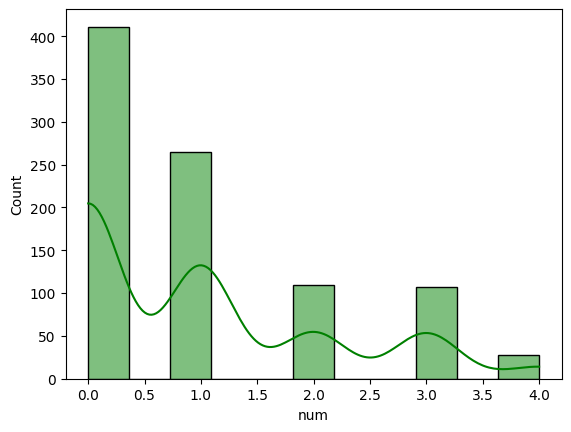

In [16]:
sns.histplot(df['num'], kde=True, color="green")

In [17]:
print(df.columns)

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='str')


In [18]:
import pandas as pd
df["target"]=(df["num"]>0).astype(int)
print(df['target'].value_counts())

target
1    509
0    411
Name: count, dtype: int64


<Axes: xlabel='target', ylabel='Count'>

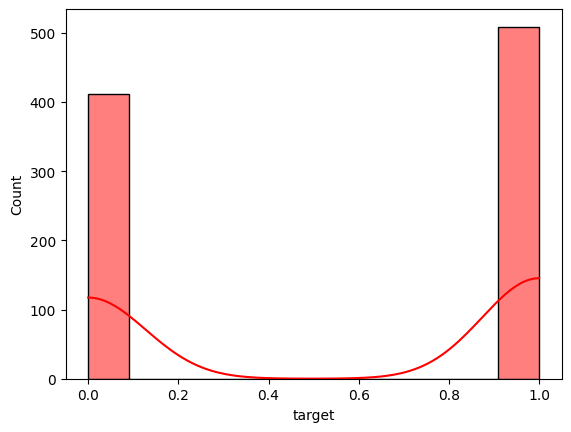

In [19]:
sns.histplot(df['target'], kde=True, color="red")

done


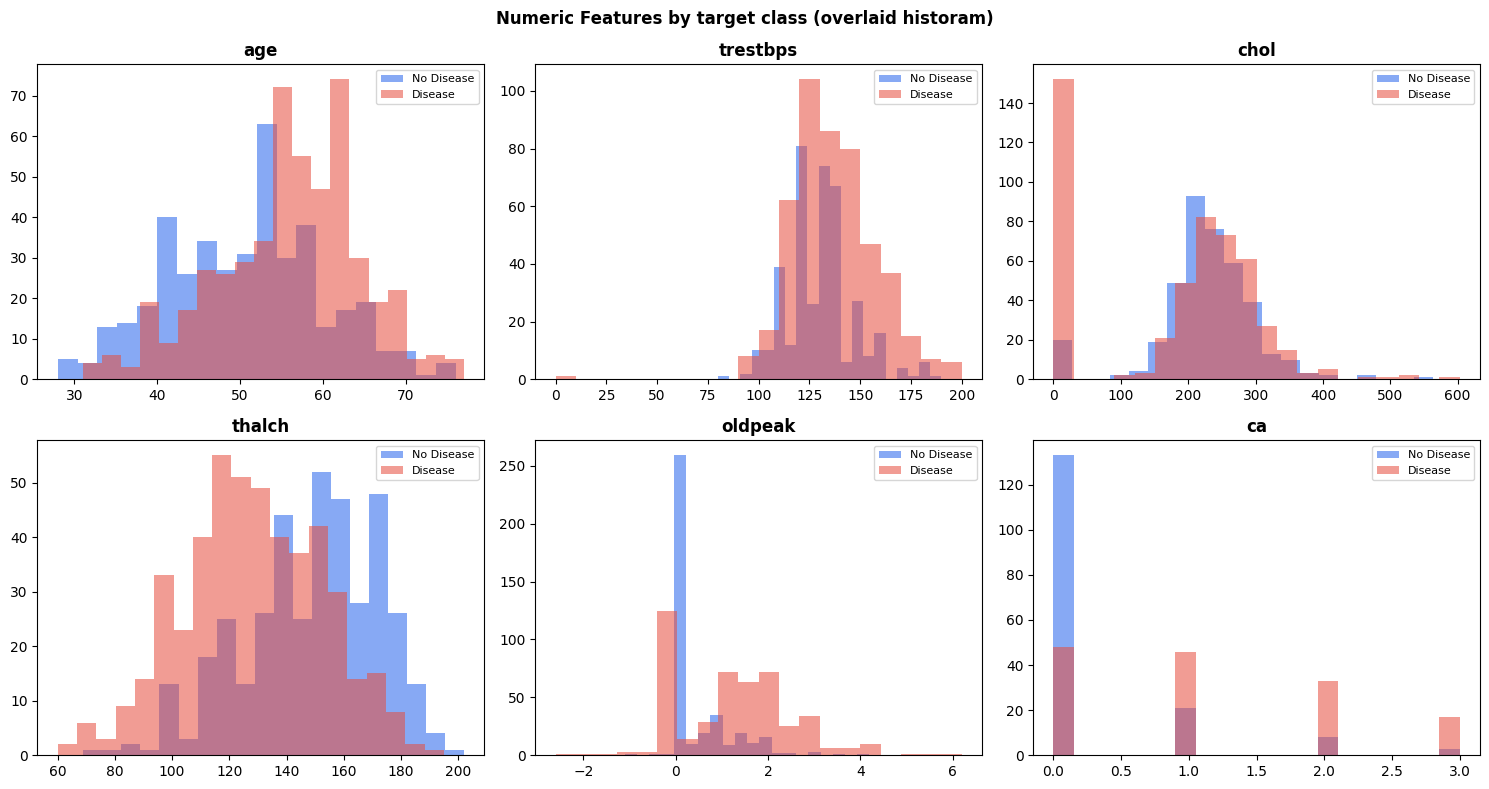

In [26]:
num_cols=["age", "trestbps", "chol", "thalch", "oldpeak", "ca"]

fig, axes=plt.subplots(2,3, figsize=(15, 8))
axes=axes.flatten()
for i, col in enumerate(num_cols):
    for label, color, name in [(0, "#2563EB", 'No Disease'), (1, '#E74C3C', 'Disease')]:
        subset=df[df['target']==label][col].dropna()
        axes[i].hist(subset, bins=20, alpha=0.55, label=name, color=color)
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)
plt.suptitle('Numeric Features by target class (overlaid historam)', fontweight='bold')
plt.tight_layout()
plt.savefig('numeric_vs_target_hist.png', dpi=130)
    


In [27]:
fig, axes=plt.subplots(1, 6, figsize=(18, 5))
for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='target', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('target (0=no disease, 1=disease')
plt.suptitle('')
plt.tight_layout()
plt.savefig('numeric_vs_target-box.png', dpi=130)
plt.close()
print("done")

done


In [12]:
get_headers=[col for col in df.columns if df[col].nunique(10) > 10]
print(get_headers)

['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak']


In [14]:
get_header=[col for col in df.columns]
print(get_header)

['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


In [16]:
print(df.shape)

(920, 16)


In [18]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB
None


In [4]:
# CHECK MISSING VALUES
print(df.isnull().sum())

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [5]:
df.head(5)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


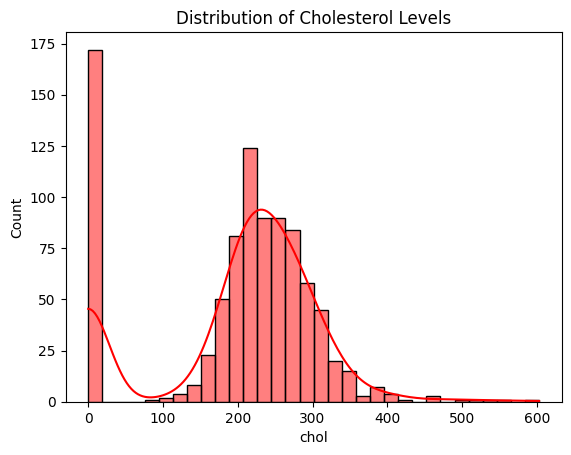

In [28]:
sns.histplot(df["chol"], kde=True,color="Red")
plt.title("Distribution of Cholesterol Levels")
plt.show()



### 1. Which variables do you pick for Skewness?
Skewness only makes sense for **Continuous Numerical Variables** (measurements that can be any number, like 120.5 or 180.2). You do **not** check skewness for categorical variables (like Sex or Chest Pain Type).

**In the Heart Disease dataset, you pick these 5:**
1.  **`age`**: To see if your dataset is mostly old people (Right-skewed) or young people (Left-skewed).
2.  **`trestbps` (Blood Pressure)**: Usually has a "Right Tail" because some people have dangerously high blood pressure.
3.  **`chol` (Cholesterol)**: Almost always has extreme outliers on the high end.
4.  **`thalach` (Max Heart Rate)**: Often "Left-skewed" because as we get older or sicker, our heart rate capacity drops.
5.  **`oldpeak` (ST Depression)**: This is the **most important** one for skewness. Most healthy people have 0. If someone has a 4 or 5, they are very sick. This creates a massive "Right Tail."

**Wizard Tip (The "Rule of Thumb"):**
If a variable has a **Skewness Score > 1 or < -1**, it is "Highly Skewed."
*   *Action:* You should consider a `Log Transform` or `Power Transform` to make the distribution look like a Bell Curve.

---

### 2. How do you pick variables for Multivariate Analysis?
You don't just pick "any" variables. You pick them based on three specific **Wizard Goals**:

#### Goal A: The "Signal Search" (Features vs. Target)
You want to see which variables actually "move the needle" for heart disease.
*   **The Move:** Plot `Target` against everything else.
*   **What to look for:** If you plot `Max Heart Rate` vs `Target` and you see that sick people (1) have significantly lower heart rates than healthy people (0), you have found a **Primary Signal**.

#### Goal B: The "Redundancy Check" (Feature vs. Feature)
You want to see if two variables are telling the exact same story. 
*   **The Move:** Look for high numbers in your Correlation Heatmap (e.g., > 0.80).
*   **What to look for:** In some datasets, `Age` and `Blood Pressure` might be so highly correlated that keeping both just "confuses" the model.
*   **The Decision:** If two variables are redundant, **drop the one that has a weaker correlation with the target.**

#### Goal C: The "Interaction Discovery" (Triangle of Truth)
Sometimes one variable is boring, but two together are explosive.
*   **Example:** `Cholesterol` by itself might not be that predictive. `Age` by itself might be okay. But **`Cholesterol` + `Age`** together might be the "Smoking Gun."
*   **The Move:** Use a `Pairplot` but color the dots by the `Target`.

---

### The Wizard's Python Logic for Selection

Instead of manually typing every name, use this code to automatically separate your "Skewness Candidates" from your "Categorical Signals."

```python
# 1. IDENTIFY CONTINUOUS VARIABLES (For Skewness & Scaling)
# We pick columns with more than, say, 10 unique values
continuous_vars = [col for col in df.columns if df[col].nunique() > 10]
print(f"Skewness Candidates: {continuous_vars}")

# 2. IDENTIFY CATEGORICAL VARIABLES (For Bivariate/One-Hot Encoding)
categorical_vars = [col for col in df.columns if df[col].nunique() <= 10 and col != 'target']
print(f"Categorical Signals: {categorical_vars}")

# --- THE SKEWNESS TEST ---
for col in continuous_vars:
    skew_val = df[col].skew()
    if abs(skew_val) > 0.75:
        print(f"WARNING: {col} is skewed ({skew_val:.2f}). Needs transformation!")

# --- THE MULTIVARIATE SEARCH ---
# Let's pick the top 3 continuous vars and top 3 categorical vars 
# to see how they interact with the target.
top_vars = ['age', 'thalach', 'oldpeak', 'cp', 'ca', 'thal']
sns.pairplot(df[top_vars + ['target']], hue='target', corner=True, palette='coolwarm')
plt.show()
```

### Summary of the Selection Mindset:
1.  **Skewness:** Only measurements (`age`, `chol`, `bp`).
2.  **Multivariate:** 
    *   Compare **measurement vs target** (to see the "gap" between sick and healthy).
    *   Compare **measurement vs measurement** (to find redundant "twins").
    *   Compare **category vs target** (to see which "types" of pain or sex are higher risk).

If you follow this, you aren't just "plotting data"; you are **filtering for truth.**

In [6]:
# . Use Automation Spells to analyze everything at once.

stats=df.describe().T
stats
stats['skew']=df.skew()
print(stats[['mean', 'std', '50%', 'skew']])

TypeError: Cannot perform reduction 'skew' with string dtype

In [ ]:
num_cols=['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
fig, axes=plt.subplots(len(num_cols), 2, figsize=(28, 18))

for i, col in enumerate(num_cols):
    # Histogram shows the shape (skewnes)
    sns.histplot(df[col], kde=True, ax=axes[i,0], color='skyblue')
    sns.boxplot(x=df[col], ax=axes[i, 1], color='lightcoral')
plt.tight_layout()
plt.show()


### Row 1: `age` (The Clean Witness)
*   **Analysis:** The histogram is beautifully symmetric (Bell Curve). The boxplot shows no dots outside the whiskers.
*   **Wizard Verdict:** This data is "Normal." It needs no special treatment other than standard scaling later.
*   **Math Check:** The Mean and Median are likely the same (~55).

### Row 2: `trestbps` (The Medical Mystery)
*   **Analysis:** Look at the far left of the histogram and boxplot. Do you see that tiny dot near **0**?
*   **The Crime:** A human being cannot have a resting blood pressure of 0 and be alive. 
*   **The Fix:** This is a "placeholder" for a missing value. You must find that row and replace the 0 with the **Median** (around 130).
*   **Math Check:** The right-side tail is "long," meaning it is **Right-Skewed**. You have several high-BP outliers (>175).

#### 1. Fix the "Zero Crimes" (Imputation)
You need to tell Python: "If BP or Cholesterol is 0, it's actually a mistake. Fix it."
```python
# Replace 0 with NaN so we can calculate the true median
df['trestbps'] = df['trestbps'].replace(0, np.nan)
df['chol'] = df['chol'].replace(0, np.nan)

# Fill those NaNs with the median
df['trestbps'] = df['trestbps'].fillna(df['trestbps'].median())
df['chol'] = df['chol'].fillna(df['chol'].median())
```

### Row 3: `chol` (The "Dead Man" Error)
*   **Analysis:** Again, look at the far left. You have a massive spike at **0**.
*   **The Crime:** Cholesterol of 0 is biologically impossible. Like the blood pressure, this is corrupted data or a missing value marked as 0.
*   **The Fix:** You **must** fix the 0s before training. If you don't, the model will think "Cholesterol of 0" is a real thing and get confused. 
*   **Math Check:** On the right side, you have a patient with cholesterol near **600**. This is a "Super Outlier."
  
#### Fix B: Robust Scaling (Best for `chol` and `trestbps`)
Because you have many outliers (circles), a standard `StandardScaler` will fail. It uses the **Mean**, which is easily fooled by outliers. You should use **`RobustScaler`**.
*   **Why:** It scales data using the **Median** and **IQR**, meaning it completely ignores the "circles" when deciding how to scale the rest of the data.

```python
from sklearn.preprocessing import RobustScaler

# Initialize the scaler
scaler = RobustScaler()

# Scale the columns that have outliers
cols_to_scale = ['trestbps', 'chol', 'thalach', 'oldpeak']
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
```
### Row 4: `thalach` (Max Heart Rate)
*   **Analysis:** This is slightly **Left-Skewed** (the tail goes to the left).
*   **The Observation:** You have two outliers on the low end (around 70-80). 
*   **Wizard Verdict:** In a heart disease context, a very low Max Heart Rate is a huge "red flag" (Signal). Do not delete these outliers! They are likely your sickest patients.


#### Fix C: Capping / Winsorization (The "Last Resort")
If an outlier is truly crazy (like the cholesterol of 600) and you think it's a measurement error, you can "cap" it at the 99th percentile.

```python
# Any value above the 99th percentile gets set to the 99th percentile value
upper_limit = df['chol'].quantile(0.99)
df['chol'] = np.where(df['chol'] > upper_limit, upper_limit, df['chol'])
```

---

### Summary Checklist for your Heart Disease Data:
1.  **Check for 0s:** Fix those 0 values in `chol` and `trestbps` using the median (as we discussed in the last step).
2.  **Calculate Outliers:** Use the `find_outliers_iqr` function above to see exactly who those "circles" are.
3.  **Transform `oldpeak`:** Use `np.log1p` to fix that massive right-skewed wall.
4.  **Scale with `RobustScaler`:** This is your best defense against those circles during the actual machine learning phase.

### Row 5: `oldpeak` (The "Signal" Variable)
*   **Analysis:** This is **Highly Right-Skewed**. Look at the histogram; it’s basically a wall at 0.
*   **The Logic:** Most people (healthy) have 0. Only the sick people have values of 2, 4, or 6. 
*   **The Problem:** Linear models (Logistic Regression) hate this shape. They want a bell curve.
*   **Wizard Verdict:** This variable is the "Smoking Gun" for heart disease, but its shape is messy.


#### Fix A: The Log Transformation (Best for `oldpeak`)
For right-skewed data with zeros (like `oldpeak`), we use `log1p`. 
*   **Why:** `log(0)` is impossible (math error), so `log1p` adds 1 to everything before taking the log. This "squashes" the high values together.

```python
import numpy as np

# Apply Log Transformation to 'oldpeak'
df['oldpeak_log'] = np.log1p(df['oldpeak'])

# Now look at the new histogram—it will look much more like a Bell Curve!
sns.histplot(df['oldpeak_log'], kde=True)


```

### 2. The Code: How to calculate if a value is an outlier
To be 100% sure a value is an outlier, you use the **IQR Method** in your code. This is exactly what the box plot is doing behind the scenes.

```python
def find_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify the outliers
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    print(f"--- Outlier Report for {column} ---")
    print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
    print(f"Total Outliers found: {len(outliers)}")
    return outliers

# Try it on your Cholesterol column
chol_outliers = find_outliers_iqr(df, 'chol')
```

---

### 3. Fixing the Skewness (The Transformation Spells)
Skewness (like in your `oldpeak` plot) pulls the "tail" of the data too far. Linear models hate this because they try to "reach" for those far-away points, which ruins the accuracy for the normal points.


---

### Your "Wizard" To-Do List (What to do Next)

You cannot move to training yet. You must perform **Data Surgery** based on these plots:



#### 2. Address the Skewness in `oldpeak`
Since `oldpeak` is so skewed, standard scaling might not be enough. You should use a **RobustScaler** or a **Log Transformation** so the outliers don't "pull" the math too far.
*   *Math Principle:* A Log transform $log(1+x)$ "squashes" the high values (4, 5, 6) closer to the 0s, making the distribution look more like a bell.





In [36]:
df['trestbps']=df['trestbps'].replace(0, np.nan)
df['chol']=df['chol'].replace(0, np.nan)
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [38]:
# Fill those NaNs with  the median
df['trestbps']=df['trestbps'].fillna(df['trestbps'].median())
df['chol']=df['chol'].fillna(df['chol'].median())

df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,130.0,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,130.0,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [44]:
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()
cols_to_scale=['trestbps', 'chol', 'thalch', 'oldpeak']

df[cols_to_scale]=scaler.fit_transform(df[cols_to_scale])
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,0.75,-0.131980,True,lv hypertrophy,0.270270,False,1.200000,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,1.50,0.944162,False,lv hypertrophy,-0.864865,True,0.666667,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,-0.50,-0.213198,False,lv hypertrophy,-0.297297,True,1.400000,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,0.00,0.213198,False,normal,1.270270,False,2.000000,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,0.00,-0.720812,False,lv hypertrophy,0.864865,False,0.600000,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,-0.15,1.898477,True,st-t abnormality,0.378378,False,-0.333333,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,0.00,-2.040609,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,-0.40,-0.335025,True,st-t abnormality,-1.081081,False,-0.333333,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,0.00,2.954315,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [7]:
def find_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify the outliers
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    print(f"--- Outlier Report for {column} ---")
    print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
    print(f"Total Outliers found: {len(outliers)}")
    return outliers

# Try it on your Cholesterol column
chol_outliers = find_outliers_iqr(df, 'chol')

--- Outlier Report for chol ---
Lower Bound: 35.50, Upper Bound: 407.50
Total Outliers found: 183


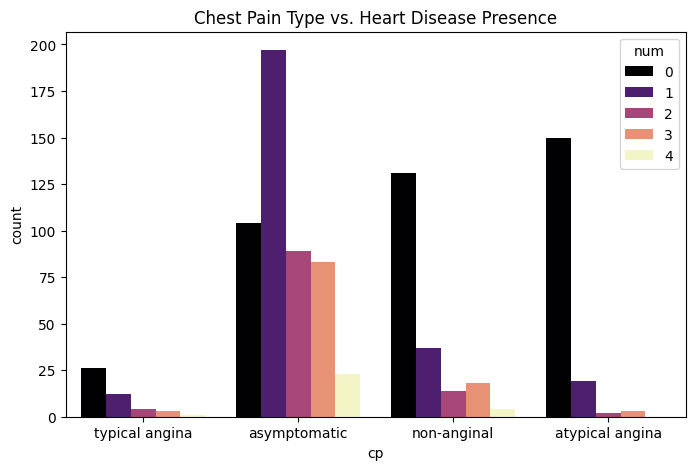

In [11]:
# --- 3. THE CATEGORICAL SIGNAL (Bivariate) ---
# Does Chest Pain (cp) actually predict Heart Disease?
# Wizard Move: We use a cross-tabulation to see the percentage.
plt.figure(figsize=(8, 5))
sns.countplot(x='cp', hue='num', data=df, palette='magma')
plt.title("Chest Pain Type vs. Heart Disease Presence")
plt.show()



In [13]:
# --- 4. THE CORRELATION HEATMAP (Multivariate) ---
plt.figure(figsize=(12, 8))
# We convert target to binary (0 = healthy, >0 = sick) for the correlation
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title("Feature Correlation: Looking for Redundancy")
plt.show()

ValueError: could not convert string to float: 'Male'

<Figure size 1200x800 with 0 Axes>